<a href="https://colab.research.google.com/github/sudipta007modak/practicegit/blob/main/roc_auc_logiReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score ,roc_curve,roc_auc_score,confusion_matrix

In [40]:
# Generate  2 class dataset

X,y = make_classification(n_samples=1000 , n_classes=2,random_state=1)

In [41]:
# Split the dataset into train test split
X_train ,X_test ,y_train , y_test = train_test_split(X , y ,test_size=0.25 ,random_state=42)

In [42]:
# Create a dummy model with default 0 as output

dummy_model_prob = [0 for _ in range(len(y_test))]
dummy_model_prob[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [43]:
# Basic Logistic Regression Model

model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [44]:
# Prediction based on probability
model_prob = model.predict_proba(X_test)

In [45]:

model_prob[:10]

array([[9.58775327e-04, 9.99041225e-01],
       [9.03113399e-01, 9.68866009e-02],
       [5.10627964e-01, 4.89372036e-01],
       [1.89953026e-01, 8.10046974e-01],
       [8.87573193e-01, 1.12426807e-01],
       [5.60127995e-01, 4.39872005e-01],
       [1.70539186e-01, 8.29460814e-01],
       [2.86177560e-01, 7.13822440e-01],
       [1.12292117e-01, 8.87707883e-01],
       [1.32026145e-01, 8.67973855e-01]])

In [46]:
# Let focus on outcome 1.
model_prob = model_prob[:,1]
len(model_prob)

250

In [47]:
dummy_model_auc = roc_auc_score(y_test , dummy_model_prob)
model_auc = roc_auc_score(y_test , model_prob)

print(dummy_model_auc)
print(model_auc)

0.5
0.9108885464817668


In [48]:
# Calculate ROC Curves
dummy_fpr , dummy_tpr , dummy_thresolds = roc_curve(y_test , dummy_model_prob)
model_fpr , model_tpr , model_thresolds = roc_curve(y_test , model_prob)

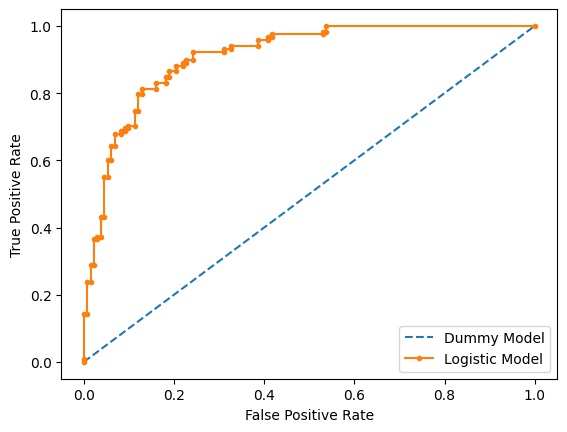

In [49]:
# plot the roc curves for the model

plt.plot(dummy_fpr ,  dummy_tpr ,linestyle = '--' ,label='Dummy Model')
plt.plot(model_fpr , model_tpr , marker = '.' ,label='Logistic Model')

# axiz labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Displlay Legend
plt.legend()

# Show the PLot
plt.show()

In [50]:
dummy_thresolds

array([inf,  0.])

In [51]:
model_thresolds

array([           inf, 9.99738397e-01, 9.87033757e-01, 9.86362468e-01,
       9.57744551e-01, 9.57101721e-01, 9.45385188e-01, 9.40463485e-01,
       9.28300276e-01, 9.27356342e-01, 9.25607881e-01, 9.23728474e-01,
       8.94744248e-01, 8.94036983e-01, 8.43395917e-01, 8.38396411e-01,
       8.28791784e-01, 8.26684852e-01, 8.08489957e-01, 8.06352720e-01,
       7.80393330e-01, 7.63976766e-01, 7.63705186e-01, 7.63537905e-01,
       7.58496683e-01, 7.55347574e-01, 7.52623720e-01, 7.48020931e-01,
       7.23488083e-01, 7.23238629e-01, 6.74619385e-01, 6.56791269e-01,
       6.55162225e-01, 6.26882105e-01, 5.99962989e-01, 5.57931518e-01,
       5.39053079e-01, 5.14219160e-01, 5.05342549e-01, 4.96278090e-01,
       4.90154702e-01, 4.85201910e-01, 4.69275954e-01, 4.50983178e-01,
       4.46563018e-01, 4.39872005e-01, 4.24245353e-01, 3.24715881e-01,
       3.12906913e-01, 3.06694053e-01, 3.01325247e-01, 2.10358834e-01,
       2.06296724e-01, 1.91030219e-01, 1.69877066e-01, 1.42771985e-01,
      

** Plot roc curve for the model with thresolds**

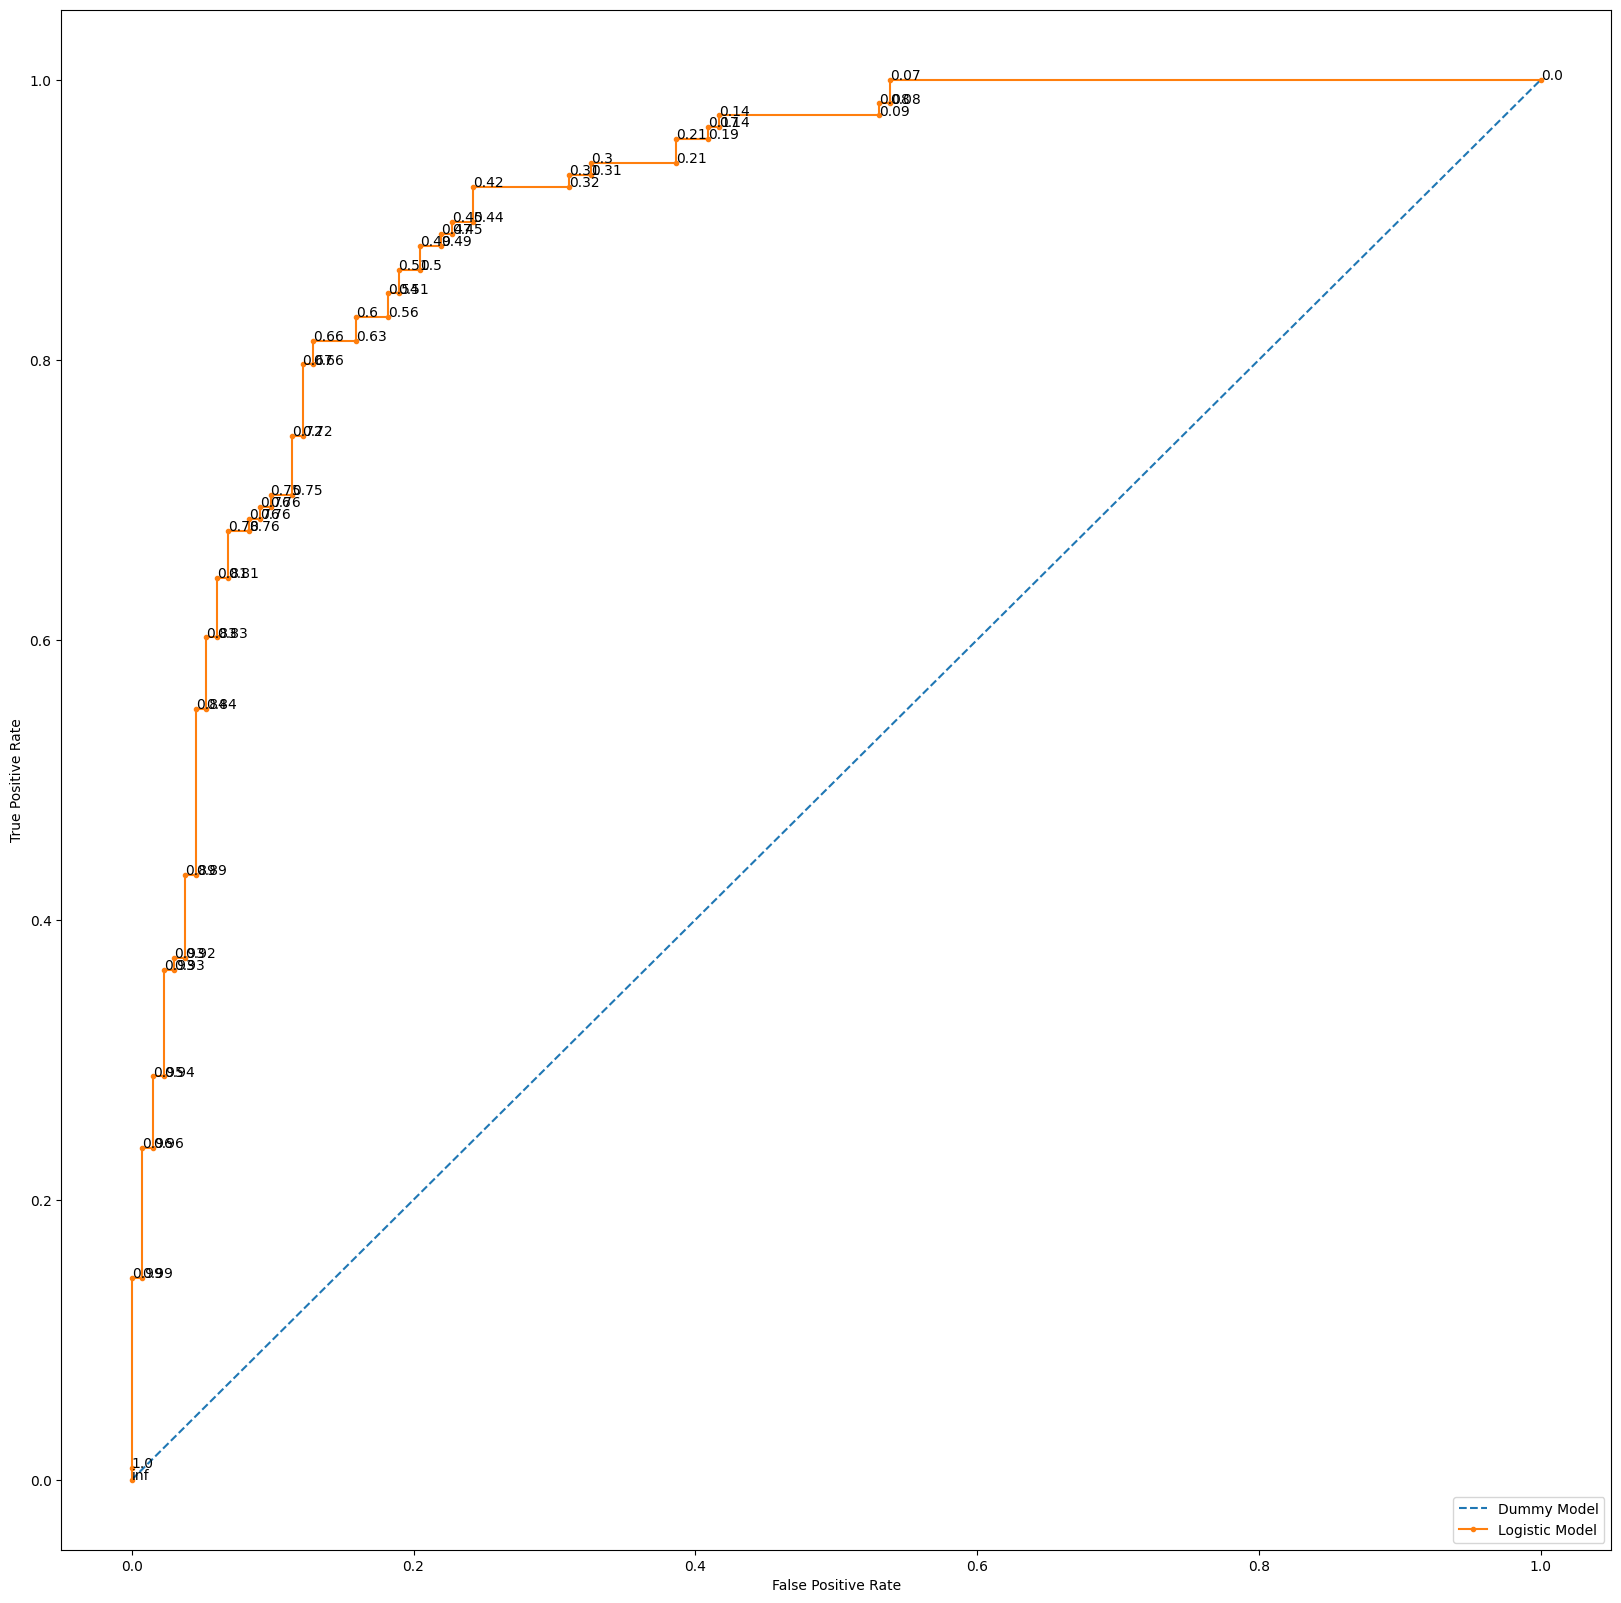

In [52]:
fig , ax = plt.subplots(figsize=(20,20))
plt.plot(dummy_fpr ,  dummy_tpr ,linestyle = '--' ,label='Dummy Model')
plt.plot(model_fpr , model_tpr , marker = '.' ,label='Logistic Model')

#ax = fig.add_subplot(111)
for xyz in zip(model_fpr ,model_tpr , model_thresolds):
    ax.annotate('%s' % np.round(xyz[2],2) , xy=(xyz[0] , xyz[1]))

# axis labels

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Displlay Legend
plt.legend(loc='lower right')

# Show the PLot
plt.show()